In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [4]:
df = pd.read_excel('/Data Set Graded Assignment 2.xlsx')
df.head(10)

,Customer_ID,Region,Sales_Channel,Product_Type,Customer_Age,Customer_Gender,Units_Purchased,Unit_Price,Discount_Percentage,Delivery_Time_Days,Payment_Mode,AI_Recommendation_Score,Customer_Satisfaction_Score,Quarter,Year
0,C5915,West,Mobile App,Clothing,28,Male,11,852.80,20,6,Debit Card,0.48,2,Q4,2024
1,C2428,East,Retail Store,Furniture,42,Male,17,600.47,14,7,UPI,0.77,4,Q3,2023
2,C9242,East,Online,Electronics,32,Male,9,667.09,16,10,Debit Card,0.18,4,Q3,2025
3,C9780,Central,Distributor,Groceries,33,Female,8,1031.47,20,8,Debit Card,0.54,1,Q4,2024
4,C7216,North,Online,Furniture,40,Male,17,1313.19,16,7,Credit Card,0.26,5,Q4,2024
5,C2921,South,Online,Clothing,48,Female,3,1586.79,4,6,Cash on Delivery,0.72,4,Q2,2025
6,C9339,East,Distributor,Furniture,32,Male,16,1133.17,2,2,Credit Card,0.02,3,Q4,2023
7,C6316,East,Distributor,Clothing,33,Male,19,1100.55,11,4,Debit Card,0.41,4,Q4,2024
8,C3546,Central,Online,Furniture,59,Male,5,648.86,0,7,Cash on Delivery,0.08,5,Q3,2023
9,C5405,South,Distributor,Clothing,65,Female,20,1776.89,10,2,Debit Card,0.94,1,Q4,2025


In [5]:
df.shape

(700, 15)

In [6]:
df.isnull().sum()

,0
Customer_ID,0
Region,0
Sales_Channel,0
Product_Type,0
Customer_Age,0
Customer_Gender,0
Units_Purchased,0
Unit_Price,0
Discount_Percentage,0
Delivery_Time_Days,0


MOST SELLING PRODUCTS?

In [8]:
boughts = df.groupby('Product_Type').agg({'Units_Purchased': 'sum'}).sort_values('Units_Purchased',ascending=False)
boughts.head()

,Units_Purchased
Product_Type,
Furniture,1489
Pharmacy,1488
Electronics,1458
Groceries,1417
Clothing,1362


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Furniture'),
  Text(1, 0, 'Pharmacy'),
  Text(2, 0, 'Electronics'),
  Text(3, 0, 'Groceries'),
  Text(4, 0, 'Clothing')])

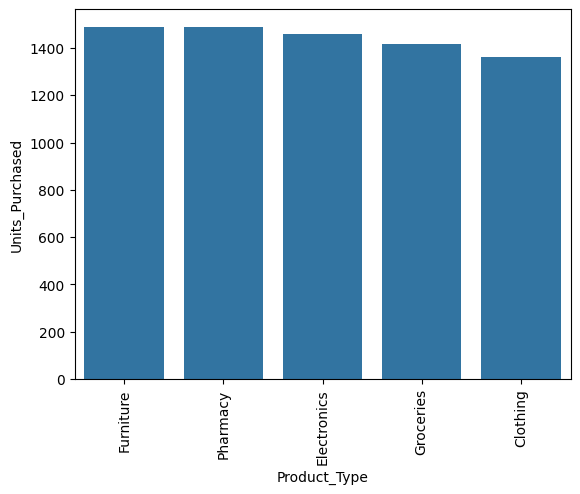

In [9]:
sns.barplot(x='Product_Type',y='Units_Purchased',data=boughts.reset_index())
plt.xticks(rotation = 'vertical')

TOP 10 PRODUCTS BY SALES? (most profitable products as well)

In [10]:
df['Sales'] = df['Units_Purchased'] * df['Unit_Price']
productSales = df.groupby('Product_Type')['Sales'].sum().sort_values(ascending=False)
productSales.head(10)

,Sales
Product_Type,
Furniture,1622877.38
Clothing,1600815.25
Electronics,1572201.26
Groceries,1505548.89
Pharmacy,1474345.73


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Furniture'),
  Text(1, 0, 'Clothing'),
  Text(2, 0, 'Electronics'),
  Text(3, 0, 'Groceries'),
  Text(4, 0, 'Pharmacy')])

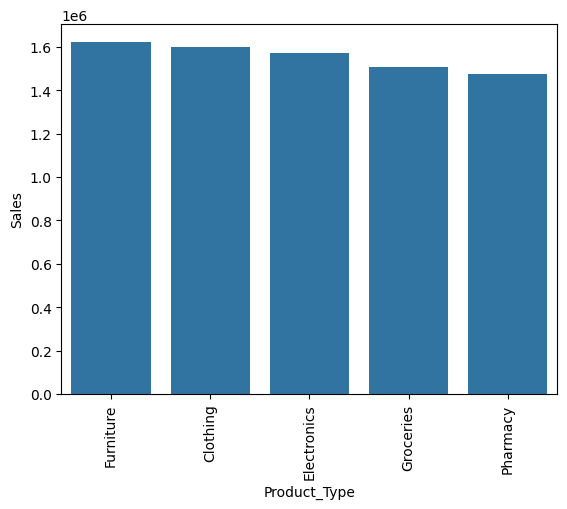

In [13]:
sns.barplot(x='Product_Type', y= 'Sales', data=profitable_products.head(10).reset_index())
plt.xticks(rotation = 'vertical')

CATEGORY THAT SOLD THE MOST

In [15]:
df.groupby('Product_Type')['Sales'].sum().sort_values(ascending = False)

,Sales
Product_Type,
Furniture,1622877.38
Clothing,1600815.25
Electronics,1572201.26
Groceries,1505548.89
Pharmacy,1474345.73


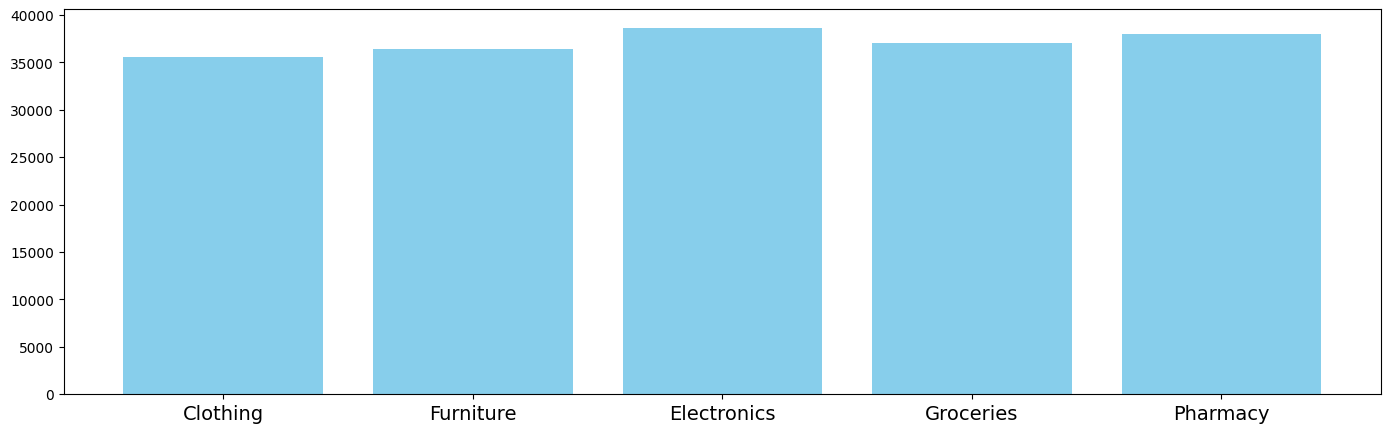

In [25]:
plt.figure(figsize=(17, 5))
plt.bar(df['Product_Type'], df['Sales'], color = 'skyblue')
plt.xticks(size=14)
plt.show()

SALES BY REGION AND CHANNEL

In [20]:
sales_by_region_channel = df.groupby(['Region', 'Sales_Channel'])['Sales'].sum().sort_values(ascending=False)
display(sales_by_region_channel)

,,Sales
Region,Sales_Channel,
Central,Mobile App,563467.84
North,Retail Store,535498.97
South,Distributor,533765.92
West,Retail Store,486574.93
East,Distributor,453372.70
Central,Distributor,448818.78
South,Mobile App,397214.18
East,Online,393839.36
North,Mobile App,388440.04


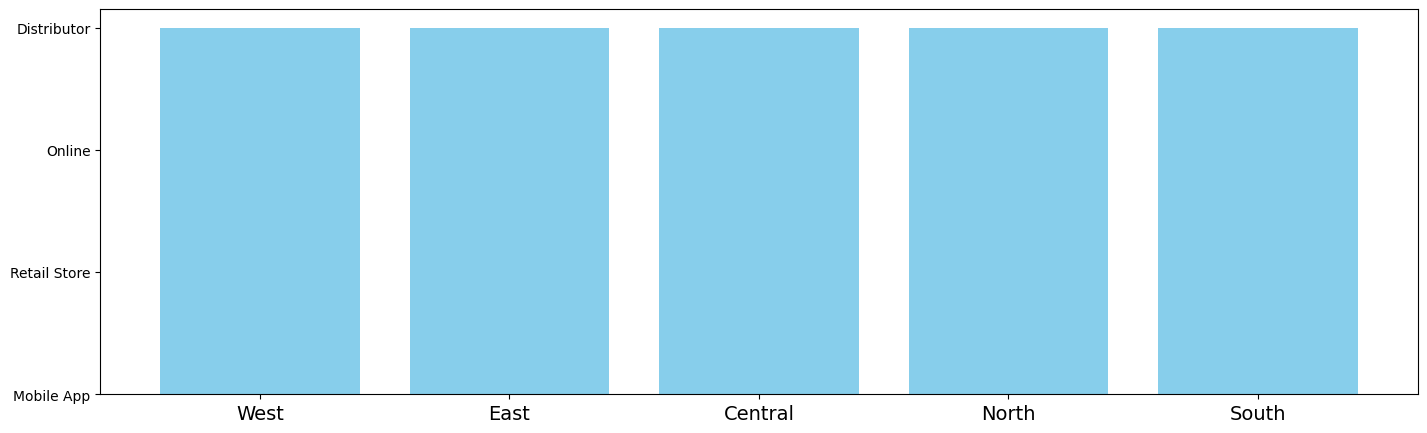

In [24]:
plt.figure(figsize=(17, 5))
plt.bar(df['Region'], df['Sales_Channel'], color = 'skyblue')
plt.xticks(size=14)
plt.show()

Analyze Sales Trends Over Time


In [26]:
sales_over_time = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
sales_over_time['Period'] = sales_over_time['Year'].astype(str) + '-' + sales_over_time['Quarter']
sales_over_time.head()

,Year,Quarter,Sales,Period
0,2023,Q1,563376.59,2023-Q1
1,2023,Q2,797906.52,2023-Q2
2,2023,Q3,601646.76,2023-Q3
3,2023,Q4,510915.57,2023-Q4
4,2024,Q1,728522.43,2024-Q1


/tmp/ipython-input-239/1274571098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Sales', data=sales_over_time, palette='viridis')


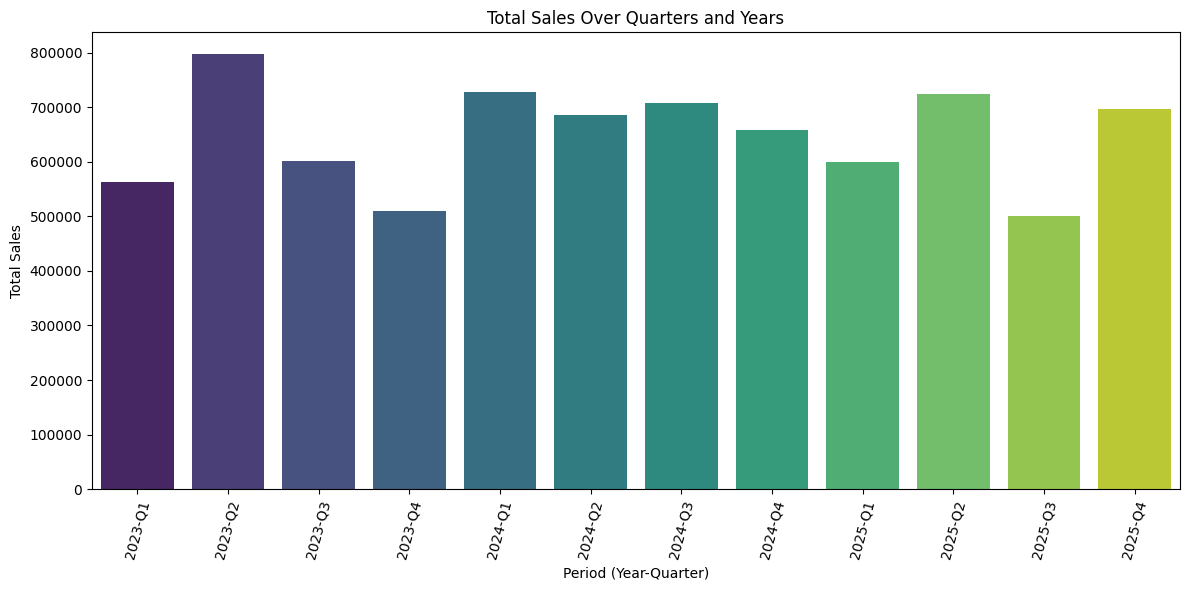

In [27]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Period', y='Sales', data=sales_over_time, palette='viridis')
plt.xticks(rotation=75)
plt.xlabel('Period (Year-Quarter)')
plt.ylabel('Total Sales')
plt.title('Total Sales Over Quarters and Years')
plt.tight_layout()
plt.show()

Analyze Sales by Customer Age Groups



In [30]:
import numpy as np
bins = [0, 25, 45, 65, df['Customer_Age'].max() + 1]
labels = ['Young Adult', 'Adult', 'Senior Adult', 'Elderly']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=True)
df.head()

,Customer_ID,Region,Sales_Channel,Product_Type,Customer_Age,Customer_Gender,Units_Purchased,Unit_Price,Discount_Percentage,Delivery_Time_Days,Payment_Mode,AI_Recommendation_Score,Customer_Satisfaction_Score,Quarter,Year,Sales,Age_Group
0,C5915,West,Mobile App,Clothing,28,Male,11,852.80,20,6,Debit Card,0.48,2,Q4,2024,9380.80,Adult
1,C2428,East,Retail Store,Furniture,42,Male,17,600.47,14,7,UPI,0.77,4,Q3,2023,10207.99,Adult
2,C9242,East,Online,Electronics,32,Male,9,667.09,16,10,Debit Card,0.18,4,Q3,2025,6003.81,Adult
3,C9780,Central,Distributor,Groceries,33,Female,8,1031.47,20,8,Debit Card,0.54,1,Q4,2024,8251.76,Adult
4,C7216,North,Online,Furniture,40,Male,17,1313.19,16,7,Credit Card,0.26,5,Q4,2024,22324.23,Adult


In [31]:
sales_by_age_group = df.groupby('Age_Group')['Sales'].sum().reset_index()
sales_by_age_group

/tmp/ipython-input-239/1939662477.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_age_group = df.groupby('Age_Group')['Sales'].sum().reset_index()


,Age_Group,Sales
0,Young Adult,1259738.80
1,Adult,3006146.44
2,Senior Adult,3509903.27
3,Elderly,0.00


In [32]:
sales_by_age_group = df.groupby('Age_Group', observed=False)['Sales'].sum().reset_index()
sales_by_age_group

,Age_Group,Sales
0,Young Adult,1259738.80
1,Adult,3006146.44
2,Senior Adult,3509903.27
3,Elderly,0.00


/tmp/ipython-input-239/3280467170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Sales', data=sales_by_age_group, palette='viridis')


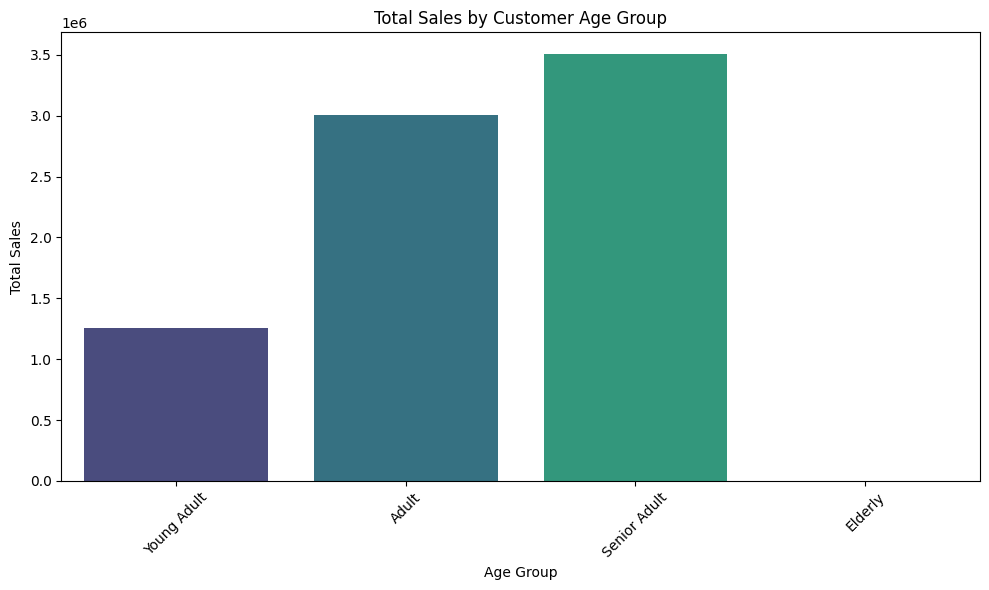

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Age_Group', y='Sales', data=sales_by_age_group, palette='viridis')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.title('Total Sales by Customer Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

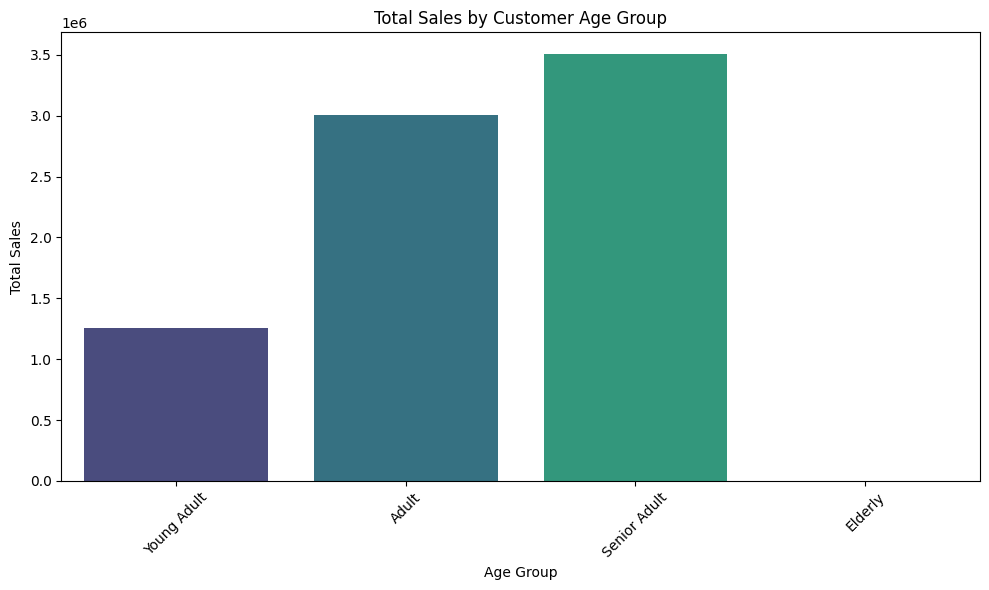

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Age_Group', y='Sales', data=sales_by_age_group, palette='viridis', hue='Age_Group', legend=False)
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.title('Total Sales by Customer Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analyze Sales by Payment Mode.


In [35]:
sales_by_payment_mode = df.groupby('Payment_Mode')['Sales'].sum().reset_index()
sales_by_payment_mode

,Payment_Mode,Sales
0,Cash on Delivery,1306914.90
1,Credit Card,1670970.52
2,Debit Card,1799301.39
3,Net Banking,1524169.25
4,UPI,1474432.45


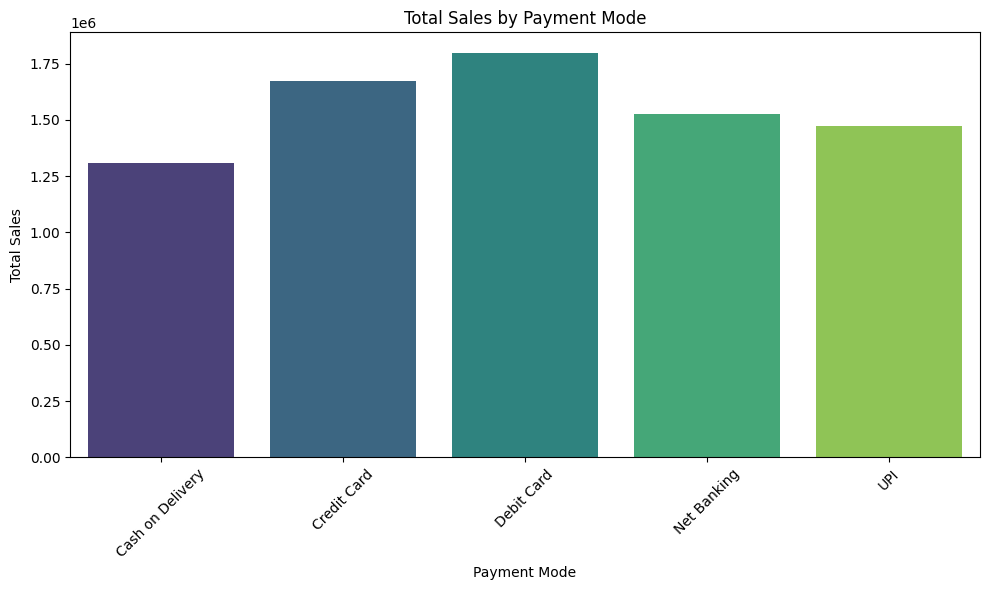

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Payment_Mode', y='Sales', data=sales_by_payment_mode, palette='viridis', hue='Payment_Mode', legend=False)
plt.xlabel('Payment Mode')
plt.ylabel('Total Sales')
plt.title('Total Sales by Payment Mode')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()